In [ ]:
from methylseqnet.dataset import BaseHDF5Dataset
from methylseqnet.peaks import selected_peaks_from_target
from pathlib import Path
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import torch
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import colors
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from collections import defaultdict
import pysam
from methylseqnet_repro.paths import configs, atac_atlas, methylation_atlas, preprocessed_datasets, annotations
from mpl_toolkits.axes_grid1 import make_axes_locatable
from adjustText import adjust_text
import h5py
from methylseqnet.metrics import pearson_per_task, fisher_mean

In [2]:
methylation_parent_folder = methylation_atlas
atlas_folder = preprocessed_datasets / "atlas"
longread_folder = preprocessed_datasets / "gm12878_haplotyped"
methylation_depth_path = annotations / "41586_2022_5580_MOESM4_ESM.xlsx"
cell_type_tsv = configs / 'cell_type_matching_atac-cage.tsv'
cell_type_df = pd.read_csv(cell_type_tsv, sep='\t')
cell_type_methyl_to_atac_quality = dict(zip(cell_type_df['Methylation_Atlas'], cell_type_df['ATAC_Match_Quality']))
cell_type_methyl_to_cage_quality = dict(zip(cell_type_df['Methylation_Atlas'], cell_type_df['CAGE_Match_Quality']))
methyl_atlas_df = pd.read_excel(
    methylation_depth_path,
    sheet_name="Table S1",
    header=2,
)
cell_type_methyl_to_read_depth = dict([
    (
        methyl_cell_type,
        methyl_atlas_df[methyl_atlas_df['Sample name'].str.contains(methyl_cell_type)]['CpG coverage (fragments)'].sum())
    for methyl_cell_type in cell_type_df['Methylation_Atlas']
])
print(cell_type_methyl_to_read_depth)
def rowwise_corrcoef(X, y):
    # Center
    X_c = X - X.mean(axis=1, keepdims=True)
    y_c = y - y.mean()
    # Correlations
    num = X_c @ y_c
    denom = np.sqrt((X_c**2).sum(axis=1) * (y_c**2).sum())
    return num / denom

{'Pancreas-Acinar': 133.22, 'Adipocytes': 96.36, 'Pancreas-Alpha': 91.88999999999999, 'Lung-Alveolar-Endothel': 106.39999999999999, 'Lung-Alveolar-Epithel': 116.32, 'Lung-Alveolar-Macrophages': 67.84, 'Coronary-Artery-Smooth-Muscle': 33.1, 'Blood-B': 126.94, 'Blood-B-Mem': 42.94, 'Breast-Basal-Epithel': 95.88000000000001, 'Pancreas-Beta': 78.99000000000001, 'Lung-Bronchus-Epithel': 118.67999999999999, 'Bronchus-Smooth-Muscle': 27.94, 'Heart-Cardiomyocyte': 114.02000000000001, 'Pancreas-Delta': 70.39, 'Pancreas-Duct': 106.21, 'Aorta-Endothel': 57.03, 'Gallbladder-Epithel': 24.6, 'Bone_marrow-Erythrocyte_progenitors': 110.85, 'Heart-Fibroblasts': 112.42999999999999, 'Kidney-Glomerular-Endothel': 104.61, 'Kidney-Glomerular-Epithel': 56.64, 'Kidney-Glomerular-Podocytes': 95.49, 'Blood-Granulocytes': 96.88, 'Liver-Hepatocytes': 209.48000000000002, 'Lung-Interstitial-Macrophages': 104.86, 'Pancreas-Islet-Endothel': 29.76, 'Epidermal-Keratinocytes': 31.24, 'Colon-Left-Endocrine': 38.47, 'Colo

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


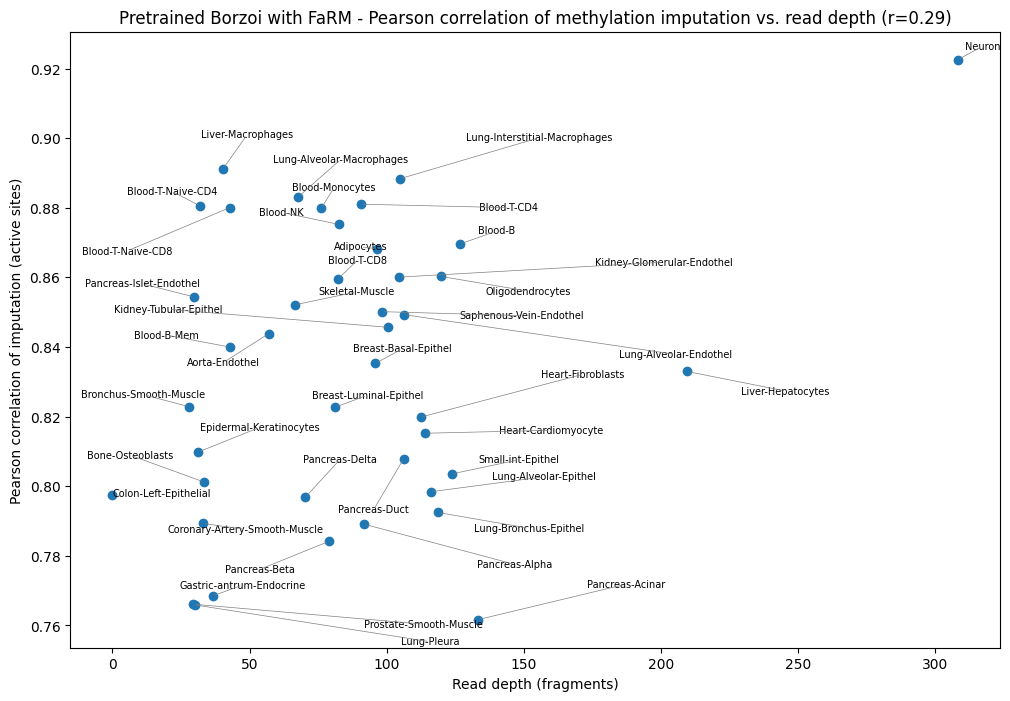

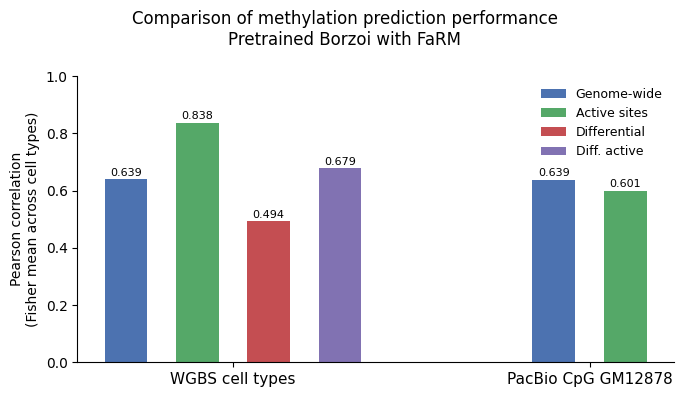

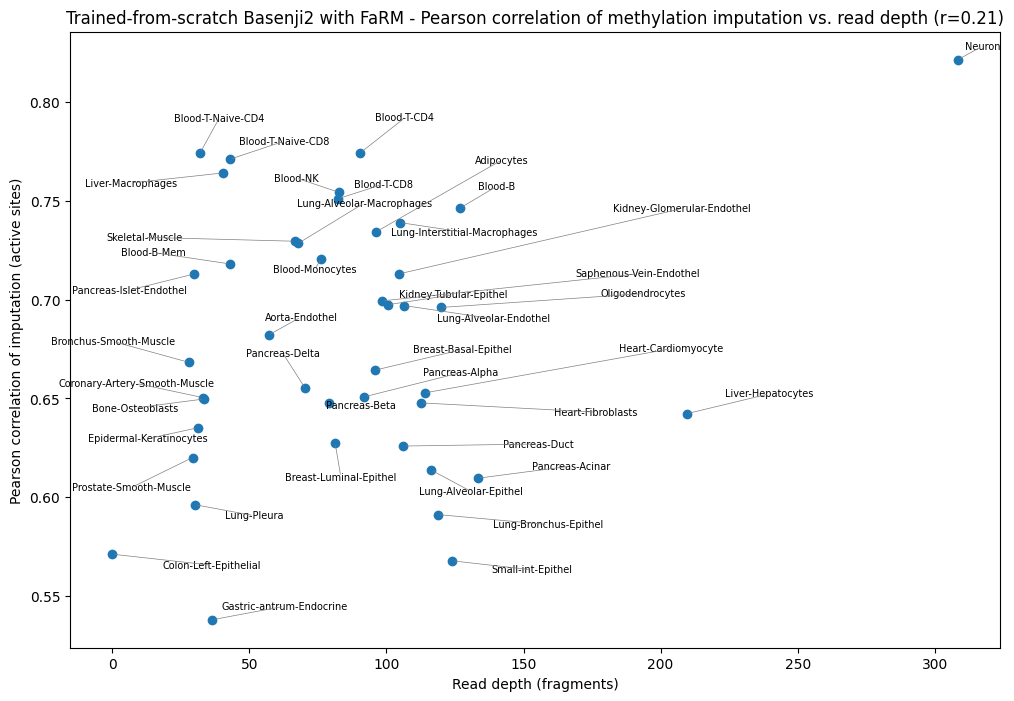

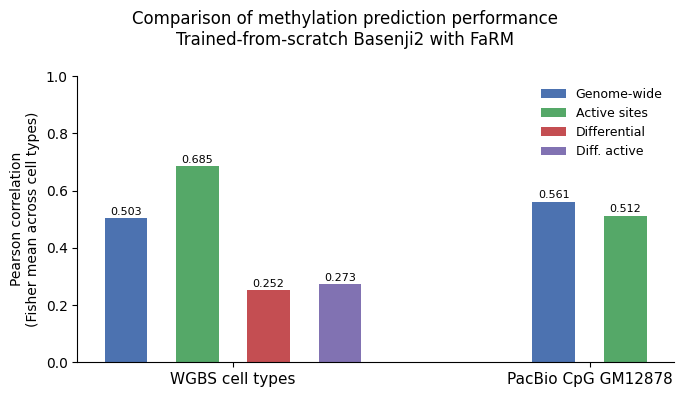

In [3]:
prediction_datasets_dict = {
    "Pretrained Borzoi with FaRM": "slurm32260895task0/fold3",
    "Trained-from-scratch Basenji2 with FaRM": "slurm32260895task5/fold3",
}

fold = 3
bin_size = 128
activations_threshold = 1
active_sites = None
active_site_threshold = 15

def collate_fn(batch):
    # Separate your data into different types
    collated_batch = {}
    for key, value in batch[0].items():
        if isinstance(value, str): 
            collated_batch[key] = [item[key] for item in batch]
        elif isinstance(value, torch.Tensor):
            collated_batch[key] = torch.stack([item[key] for item in batch])
        elif isinstance(value, np.ndarray):
            collated_batch[key] = np.stack([item[key] for item in batch])
        else:
            raise TypeError(f"Unsupported data type for key {key}: {type(value)}")
    return collated_batch
max_samples = None
active_sites = None
active_site_threshold = 15

for model_description, dataset_specifier in prediction_datasets_dict.items():
    for dataset_folder in atlas_folder, longread_folder:
        dataset_path = dataset_folder / dataset_specifier / "predictions.h5"
        if "atlas" in str(dataset_path):
            dataset = BaseHDF5Dataset(dataset_path, datasets={'true_conditioning_state_rep', 'imputed_conditioning_state_rep'}, return_specifiers=True)
            io_mappings_df = dataset.get_io_mappings_df()
            methyl_read_depth_by_celltype = {
                row['methylation_files'].strip("[]'"): cell_type_methyl_to_read_depth[row['methylation_files'].strip("[]'")]
                for idx, row in io_mappings_df.iterrows() if row['data_type'] in ["ATAC-seq","CAGE-seq"]
            }
            # print(methyl_read_depth_by_celltype)
        with h5py.File(dataset_path, 'r') as f:
            true_conditioning_state_rep = torch.tensor(f['true_conditioning_state_rep'][0:max_samples] if max_samples is not None else f['true_conditioning_state_rep'][:])
            imputed_conditioning_state_rep = torch.tensor(f['imputed_conditioning_state_rep'][0:max_samples] if max_samples is not None else f['imputed_conditioning_state_rep'][:])
            targets = torch.tensor(f['tracks'][0:max_samples,0] if max_samples is not None else f['tracks'][:,0]).squeeze() if active_sites is None else None

        reshaped_true_methylation = true_conditioning_state_rep.permute(2, 1, 3, 0).reshape(true_conditioning_state_rep.shape[1], -1)
        reshaped_imputed_methylation = imputed_conditioning_state_rep.permute(2, 1, 3, 0).reshape(imputed_conditioning_state_rep.shape[1], -1)

        if active_sites is None:
            reshaped_targets = targets.permute(1, 2, 0).reshape(targets.shape[1], -1)
            dataset = BaseHDF5Dataset(dataset_path,return_specifiers=True)
            io_mappings_df = dataset.get_io_mappings_df()
            atac_channels = io_mappings_df[io_mappings_df['data_type']=='ATAC-seq']['channel'].tolist()
            reshaped_targets_atac_max = reshaped_targets[atac_channels,:].numpy().max(axis=0)
            active_sites = selected_peaks_from_target(
                target = reshaped_targets_atac_max,
                peak_threshold = active_site_threshold,
                min_peak_distance_bins = 8,
            )
    
        fisher_mean_pearson = fisher_mean(pearson_per_task(reshaped_imputed_methylation, reshaped_true_methylation))
        fisher_mean_pearson_active = (
            fisher_mean(pearson_per_task(reshaped_imputed_methylation[:,active_sites], reshaped_true_methylation[:,active_sites]))
        )
        if "atlas" in str(dataset_path):
            differential_true_methylation = reshaped_true_methylation - reshaped_true_methylation.mean(dim=0, keepdim=True)
            differential_imputed_methylation = reshaped_imputed_methylation - reshaped_imputed_methylation.mean(dim=0, keepdim=True)
            fisher_mean_pearson_differential = fisher_mean(pearson_per_task(differential_imputed_methylation, differential_true_methylation))
            fisher_mean_pearson_differential_active = fisher_mean(pearson_per_task(differential_imputed_methylation[:,active_sites], differential_true_methylation[:,active_sites]))
            fisher_mean_pearson_atlas = fisher_mean_pearson
            fisher_mean_pearson_active_atlas = fisher_mean_pearson_active
            fisher_mean_pearson_differential_atlas = fisher_mean_pearson_differential
            fisher_mean_pearson_differential_active_atlas = fisher_mean_pearson_differential_active
            # scatterplot against read depth
            cell_type_names = list(methyl_read_depth_by_celltype.keys())
            read_depths = list(methyl_read_depth_by_celltype.values())
            per_task_pearson_active = pearson_per_task(reshaped_imputed_methylation[:,active_sites], reshaped_true_methylation[:,active_sites])
            pearson_corr_of_pearson_corrs = pearsonr(read_depths, per_task_pearson_active)[0]
            fig, ax = plt.subplots(figsize=(12,8))
            ax.scatter(read_depths, per_task_pearson_active)
            # topk = 3
            # most_improved = set(np.argsort(np.array(x)-np.array(y))[-topk:])
            # least_improved = set(np.argsort(np.array(x)-np.array(y))[:topk])
            # label_idxs = most_improved | least_improved
            texts = []
            for i in range(len(cell_type_names)):
                texts.append(ax.annotate(
                    cell_type_names[i],
                    (read_depths[i], per_task_pearson_active[i]),
                    fontsize=7,
                ))

            adjust_text(
                texts,
                ax=ax,
                expand=(2.0, 2.0),
                force_text=(2.0, 2.0),
                force_points=(2.0, 2.0),
                force_static=(1.5, 1.5),
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
                iter_lim=5000,
                only_move={'text': 'xy', 'static': 'xy', 'explode': 'xy', 'pull': 'xy'},
            )
            plt.title(f"{model_description} - Pearson correlation of methylation imputation vs. read depth (r={pearson_corr_of_pearson_corrs:.2f})")
            plt.xlabel("Read depth (fragments)")
            plt.ylabel("Pearson correlation of imputation (active sites)")

        else:
            fisher_mean_pearson_pacbio = fisher_mean_pearson
            fisher_mean_pearson_active_pacbio = fisher_mean_pearson_active

    # -- Collect your values --
    # Atlas metrics
    atlas_metrics = {
        'Genome-wide': fisher_mean_pearson_atlas,
        'Active sites': fisher_mean_pearson_active_atlas,
        'Differential': fisher_mean_pearson_differential_atlas,
        'Diff. active': fisher_mean_pearson_differential_active_atlas,
    }
    # PacBio metrics (subset)
    pacbio_metrics = {
        'Genome-wide': fisher_mean_pearson_pacbio,
        'Active sites': fisher_mean_pearson_active_pacbio,
    }

    # -- Colors for each metric type (shared across groups) --
    metric_colors = {
        'Genome-wide': '#4C72B0',
        'Active sites': '#55A868',
        'Differential': '#C44E52',
        'Diff. active': '#8172B2',
    }

    fig, ax = plt.subplots(figsize=(7, 4))
    fig.suptitle(f'Comparison of methylation prediction performance\n{model_description}', fontsize=12)

    bar_width = 0.6
    gap_between_groups = 2.0

    # Atlas bars
    atlas_x = np.arange(len(atlas_metrics))
    for i, (label, val) in enumerate(atlas_metrics.items()):
        ax.bar(atlas_x[i], val, width=bar_width, color=metric_colors[label], label=label)

    # PacBio bars (offset by group gap)
    pacbio_start = len(atlas_metrics) + gap_between_groups
    pacbio_x = pacbio_start + np.arange(len(pacbio_metrics))
    for i, (label, val) in enumerate(pacbio_metrics.items()):
        ax.bar(pacbio_x[i], val, width=bar_width, color=metric_colors[label])

    # Group labels
    atlas_center = atlas_x.mean()
    pacbio_center = pacbio_x.mean()
    ax.set_xticks([atlas_center, pacbio_center])
    ax.set_xticklabels(['WGBS cell types', 'PacBio CpG GM12878'], fontsize=11)

    # Bar labels (value on top of each bar)
    for x, val in zip(np.concatenate([atlas_x, pacbio_x]),
                    list(atlas_metrics.values()) + list(pacbio_metrics.values())):
        ax.text(x, val + 0.005, f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_ylabel('Pearson correlation\n(Fisher mean across cell types)')
    ax.set_ylim(0, 1.0)
    ax.legend(loc='upper right', frameon=False, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    fig.savefig(f"pdfs/supplement__methylation_prediction_performance_comparison_{model_description.replace(' ','_')}.pdf", bbox_inches='tight')
    plt.show()
        